# Разметка дыхания эксперимента 2

**Статус:** активный производитель кандидатной и принятой вручную дыхательной
разметки. Автоматически найденные интервалы не являются проверенным входом
последующих расчётов.

Временные метки команд прибором не записывались. Даже принятые вручную
интервалы являются экспертной ретроспективной реконструкцией по памяти автора
и форме сигнала, а не непосредственно измеренными событиями. Для каждой
границы необходимо сохранять основание и степень уверенности.

Ноутбук выделен из исторического `08_Скетч_разметки.ipynb`. Исходная смешанная
реализация сохранена в
[`archive/legacy/11.90`](archive/legacy/11.90_Скетч_механических_точек.ipynb),
а происхождение ячеек — в
[`MIGRATION_MANIFEST_2026-08-26.json`](MIGRATION_MANIFEST_2026-08-26.json).


## Входы, допущения и выход

Входом служат внешние CSV эксперимента 2 с колонками времени и базового
импеданса боковой сборки. Пути, обезличенные идентификаторы, канонические
размеры каждого добровольца и исключённые дубликаты задаются во внешнем
локальном JSON по схеме
[`config/exp02_paths.example.json`](config/exp02_paths.example.json).

Алгоритм ищет два продолжительных участка с малой локальной вариабельностью.
Первый по времени участок получает кандидатную метку задержки после вдоха, а
второй — задержки после выдоха, поскольку такой порядок восстановлен и
подтверждён автором для эксперимента 2. Различие уровней `BASE_2` используется
только как диагностическое наблюдение и не меняет метки местами.

Поиск двух наиболее продолжительных спокойных участков является эвристикой.
Изменение контакта, базового уровня, движение или слабое дыхание могут создать
похожий фрагмент. Сопоставимость последовательно записанных размеров остаётся
допущением.

Каждый сопроводительный JSON получает полный SHA-256 исходной записи, версию
алгоритма, параметры эвристики и статус `pending_manual_review`. Последующие
расчёты принимают только `accepted_modes` из артефактов со статусом `accepted`.


In [1]:
# Импорты и внешняя конфигурация
from datetime import datetime, timezone
import hashlib
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CONFIG_ENV = "KALMYKOV_EXP02_CONFIG"
config_value = os.environ.get(CONFIG_ENV)
if not config_value:
    raise RuntimeError(
        f"Задайте {CONFIG_ENV}: путь к локальному JSON по схеме "
        "config/exp02_paths.example.json"
    )

CONFIG_PATH = Path(config_value).expanduser().resolve()
CONFIG = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))
DATA_ROOT = Path(CONFIG["data_root"]).expanduser().resolve()
DERIVED_ROOT = Path(CONFIG["derived_root"]).expanduser().resolve()
subject_items = CONFIG["subjects"]
subject_ids = [item["subject_id"] for item in subject_items]
if len(subject_items) != 2 or len(subject_ids) != len(set(subject_ids)):
    raise ValueError("Эксперимент 2 должен содержать двух уникальных добровольцев")
SUBJECTS = {item["subject_id"]: item for item in subject_items}

OUT_DIR = DERIVED_ROOT / "exp02" / "annotations" / "breathing"
OUT_DIR.mkdir(parents=True, exist_ok=True)

TIME_COL = "TIME_s"
SEG_COL = "BASE_2_Ω"
ALGORITHM_VERSION = "exp02-breathing-heuristic-v2"
PARAMETERS = {
    "window_s": float(CONFIG["breathing_segmentation"]["window_s"]),
    "min_hold_s": float(CONFIG["breathing_segmentation"]["min_hold_s"]),
    "quiet_quantile": float(CONFIG["breathing_segmentation"]["quiet_quantile"]),
    "quiet_multiplier": float(CONFIG["breathing_segmentation"]["quiet_multiplier"]),
    "quiet_floor_ohm": float(CONFIG["breathing_segmentation"]["quiet_floor_ohm"]),
}
if not 0 < PARAMETERS["quiet_quantile"] < 100:
    raise ValueError("quiet_quantile задаётся в процентах от 0 до 100")
for name in ("window_s", "min_hold_s", "quiet_multiplier", "quiet_floor_ohm"):
    if not np.isfinite(PARAMETERS[name]) or PARAMETERS[name] <= 0:
        raise ValueError(f"{name} должен быть положительным")


def sha256_file(path):
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def resolve_under_data_root(path):
    resolved = path.expanduser().resolve()
    resolved.relative_to(DATA_ROOT)
    return resolved


def record_path(info, size_mm):
    directory = resolve_under_data_root(DATA_ROOT / info["data_subdir"])
    path = resolve_under_data_root(
        directory / f"{int(size_mm)}{info['filename_suffix']}.csv"
    )
    if not path.is_file():
        raise FileNotFoundError(f"Нет ожидаемой записи размера {size_mm} мм")
    return path


def read_record(path):
    frame = pd.read_csv(path, encoding="utf-8")
    missing = {TIME_COL, SEG_COL} - set(frame.columns)
    if missing:
        raise ValueError(f"В CSV отсутствуют обязательные столбцы: {sorted(missing)}")
    for column in (TIME_COL, SEG_COL):
        frame[column] = pd.to_numeric(frame[column], errors="raise")
        if not np.isfinite(frame[column].to_numpy(dtype=float)).all():
            raise ValueError(f"Столбец {column} содержит нечисловые значения")
    return frame


def sampling_frequency(frame):
    time = frame[TIME_COL].to_numpy(dtype=float)
    delta = np.diff(time)
    if len(delta) == 0 or np.any(~np.isfinite(delta)) or np.any(delta <= 0):
        raise ValueError("TIME_s должен быть конечным и строго возрастающим")
    median_dt = float(np.median(delta))
    jitter_fraction = float(np.median(np.abs(delta - median_dt)) / median_dt)
    return 1.0 / median_dt, jitter_fraction


def validate_subject_exclusions(subject_id, info):
    sizes = [int(value) for value in info["sizes_mm"]]
    if not sizes or len(sizes) != len(set(sizes)):
        raise ValueError(f"Для {subject_id} нужен уникальный непустой sizes_mm")
    exclusions = info.get("excluded_recordings", [])
    excluded_sizes = {int(item["size_mm"]) for item in exclusions}
    if excluded_sizes & set(sizes):
        raise ValueError(f"Исключённый размер включён в sizes_mm: {subject_id}")
    validated = []
    for item in exclusions:
        size_mm = int(item["size_mm"])
        duplicate_of = int(item["duplicate_of_size_mm"])
        excluded_path = record_path(info, size_mm)
        canonical_path = record_path(info, duplicate_of)
        excluded_sha = sha256_file(excluded_path)
        canonical_sha = sha256_file(canonical_path)
        if excluded_sha != canonical_sha:
            raise ValueError(
                f"Заявленный дубликат {subject_id}, {size_mm} мм "
                f"не совпадает с {duplicate_of} мм"
            )
        validated.append({
            "subject_id": subject_id,
            "size_mm": size_mm,
            "duplicate_of_size_mm": duplicate_of,
            "sha256": excluded_sha,
            "reason": item.get("reason", "byte_identical_duplicate"),
        })
    return validated


def iter_recordings():
    for subject_id, info in SUBJECTS.items():
        for size_mm in info["sizes_mm"]:
            yield subject_id, info, int(size_mm), record_path(info, size_mm)


In [2]:
# Эвристическое выделение кандидатов дыхательных режимов
def segment_breathing(frame, parameters=PARAMETERS):
    time = frame[TIME_COL].to_numpy(dtype=float)
    signal = frame[SEG_COL].to_numpy(dtype=float)
    fs, _ = sampling_frequency(frame)

    window = max(5, int(round(parameters["window_s"] * fs)))
    rolling_std = (
        pd.Series(signal)
        .rolling(window, center=True, min_periods=max(3, window // 2))
        .std()
        .to_numpy()
    )
    finite_std = rolling_std[np.isfinite(rolling_std)]
    if len(finite_std) == 0:
        return None
    threshold = max(
        parameters["quiet_floor_ohm"],
        float(
            np.percentile(finite_std, parameters["quiet_quantile"])
            * parameters["quiet_multiplier"]
        ),
    )
    quiet = np.isfinite(rolling_std) & (rolling_std < threshold)

    runs = []
    index = 0
    while index < len(quiet):
        if not quiet[index]:
            index += 1
            continue
        stop = index
        while stop < len(quiet) and quiet[stop]:
            stop += 1
        if stop > index and time[stop - 1] - time[index] >= parameters["min_hold_s"]:
            runs.append((index, stop))
        index = stop

    runs.sort(key=lambda item: -(time[item[1] - 1] - time[item[0]]))
    holds = sorted(runs[:2], key=lambda item: item[0])
    if len(holds) < 2:
        return None

    inhale, exhale = holds
    inhale_level = float(np.median(signal[inhale[0]:inhale[1]]))
    exhale_level = float(np.median(signal[exhale[0]:exhale[1]]))

    def closed_interval(segment):
        return [float(time[segment[0]]), float(time[segment[1] - 1])]

    deep_start_index = min(inhale[1], len(time) - 1)
    modes = {
        "спокойное": [float(time[0]), float(time[inhale[0]])],
        "задержка_вдох": closed_interval(inhale),
        "глубокое": [float(time[deep_start_index]), float(time[exhale[0]])],
        "задержка_выдох": closed_interval(exhale),
    }
    return {
        "candidate_modes": modes,
        "hold_levels_ohm": {
            "вдох": inhale_level,
            "выдох": exhale_level,
        },
        "observed_level_relation": {
            "inhale_higher_than_exhale": bool(inhale_level > exhale_level),
            "used_for_mode_assignment": False,
        },
        "heuristic": {
            **parameters,
            "quiet_threshold_ohm": threshold,
        },
    }


In [3]:
# Проверка исключений и построение отдельных дыхательных sidecar-файлов
validated_exclusions = []
for subject_id, info in SUBJECTS.items():
    validated_exclusions.extend(validate_subject_exclusions(subject_id, info))

for item in validated_exclusions:
    print(
        "Подтверждён байт-в-байт дубликат:",
        item["subject_id"],
        f"{item['size_mm']}→{item['duplicate_of_size_mm']} мм",
    )

records = []
record_ids = set()
for subject_id, info, size_mm, source_path in iter_recordings():
    frame = read_record(source_path)
    fs_hz, jitter_fraction = sampling_frequency(frame)
    candidate = segment_breathing(frame)
    if candidate is None:
        print("Не найдены две кандидатные задержки:", subject_id, size_mm)
        continue

    input_sha256 = sha256_file(source_path)
    record_id = input_sha256[:16]
    if record_id in record_ids:
        raise ValueError("Коллизия record_id среди независимых записей")
    record_ids.add(record_id)
    relative_path = source_path.relative_to(DATA_ROOT).as_posix()
    output = {
        "schema_version": 2,
        "annotation_type": "breathing",
        "algorithm_version": ALGORITHM_VERSION,
        "record_id": record_id,
        "subject_id": subject_id,
        "size_mm": size_mm,
        "input": {
            "relative_path": relative_path,
            "sha256": input_sha256,
            "sampling_frequency_hz": fs_hz,
            "sampling_frequency_source": "median_diff_TIME_s",
            "relative_time_step_jitter": jitter_fraction,
        },
        **candidate,
        "accepted_modes": None,
        "assumptions": [
            "two_longest_quiet_segments_are_breath_holds",
            "first_hold_is_inhale_and_second_hold_is_exhale_by_author_reconstructed_order",
            "recordings_of_different_sizes_are_comparable",
        ],
        "qc": {
            "status": "pending_manual_review",
            "reviewer": None,
            "reviewed_at": None,
            "notes": None,
            "history": [],
        },
    }
    output_path = OUT_DIR / f"{record_id}.json"
    if output_path.exists():
        existing = json.loads(output_path.read_text(encoding="utf-8"))
        if existing.get("input", {}).get("sha256") != input_sha256:
            raise RuntimeError(f"Конфликт входного SHA-256 для {record_id}")
        if existing.get("subject_id") != subject_id or existing.get("size_mm") != size_mm:
            raise RuntimeError(f"Конфликт происхождения sidecar {record_id}")
        if existing.get("algorithm_version") != ALGORITHM_VERSION:
            raise RuntimeError(
                f"Sidecar {record_id} создан другой версией алгоритма; "
                "его нужно отдельно пересмотреть или архивировать"
            )
        if (
            existing.get("qc", {}).get("status") == "accepted"
            and not existing.get("accepted_modes")
        ):
            raise RuntimeError(
                f"Принятый sidecar {record_id} не содержит accepted_modes"
            )
        records.append(existing)
        print("Сохранён существующий sidecar:", record_id, existing["qc"]["status"])
        continue

    output_path.write_text(
        json.dumps(output, ensure_ascii=False, indent=2) + "\n",
        encoding="utf-8",
    )
    records.append(output)
    print("Создан кандидат:", record_id, size_mm, output["qc"]["status"])

expected_count = int(CONFIG["expected_independent_record_count"])
configured_count = sum(len(item["sizes_mm"]) for item in subject_items)
if configured_count != expected_count:
    raise ValueError(
        f"В sizes_mm задано {configured_count} записей вместо {expected_count}"
    )
if len(records) != expected_count:
    raise RuntimeError(
        f"Получено {len(records)} sidecar-файлов вместо {expected_count}; "
        "проверьте ненайденные задержки"
    )
print("Кандидатных или ранее сохранённых sidecar-файлов:", len(records))


Подтверждён байт-в-байт дубликат: exp02_nik 100→90 мм
Сохранён существующий sidecar: af9442f5b70f4964 accepted
Сохранён существующий sidecar: 16e1fb61f5c4f94d accepted
Сохранён существующий sidecar: 74a1a7f4a6c3da1a accepted
Сохранён существующий sidecar: de3d881503ce81e8 accepted
Сохранён существующий sidecar: dc6569ff63a799cf accepted
Сохранён существующий sidecar: ebac1f4aa63db94d accepted
Сохранён существующий sidecar: 38014daebf7ff78a accepted
Сохранён существующий sidecar: c65e99bd76dba9a3 accepted
Сохранён существующий sidecar: a4131daac20b73b0 accepted
Сохранён существующий sidecar: 532548295b851498 accepted
Сохранён существующий sidecar: f230453caab02f7c accepted
Сохранён существующий sidecar: 457a9c313389d102 accepted
Сохранён существующий sidecar: 3eb16c060e856d45 accepted
Сохранён существующий sidecar: 5c3d49578fcc44a2 accepted
Сохранён существующий sidecar: 61792d81e4b89349 accepted
Сохранён существующий sidecar: f8e058ae0d2a7d5b accepted
Сохранён существующий sidecar: 381

Сохранён существующий sidecar: abb001faf8162073 accepted
Кандидатных или ранее сохранённых sidecar-файлов: 19


## Визуальная проверка и принятая разметка

Для каждой записи проверены форма базового импеданса боковой сборки, порядок
дыхательных режимов и положение устойчивых участков после вдоха и выдоха.
Приборные метки команд отсутствуют, поэтому принятые интервалы представляют
собой экспертную ретроспективную реконструкцию. Они не задают точное время
подачи команды испытуемому.

Порядок режимов «спокойное дыхание → задержка после вдоха → усиленное дыхание
→ задержка после выдоха» подтверждён автором проекта. Автор также утвердил все
19 предложений по рабочим границам. Уверенность в порядке режимов высокая, в
выборе устойчивых окон задержек — умеренная, а в точном времени команд —
низкая. В количественных расчётах следует использовать устойчивые окна
задержек, не включая переходные участки между режимами.

В записях Георга для сборок 80 и 100 мм начало окна задержки после выдоха
перенесено соответственно на 56,0 и 58,0 с: первоначальные автоматические
границы частично захватывали переход к установившемуся уровню. Остальные
кандидатные интервалы приняты без изменения после визуальной проверки.

Решения привязаны к идентификаторам записей и полным контрольным суммам
исходных CSV. Изменённая или новая запись не наследует принятую разметку
автоматически.

По поканальному решению `10.01` записи Георга 90 и 100 мм используются здесь
только для разметки канала 2. Канал 1 этих записей не участвует в выборе
дыхательных границ и не используется в совместном количественном анализе.


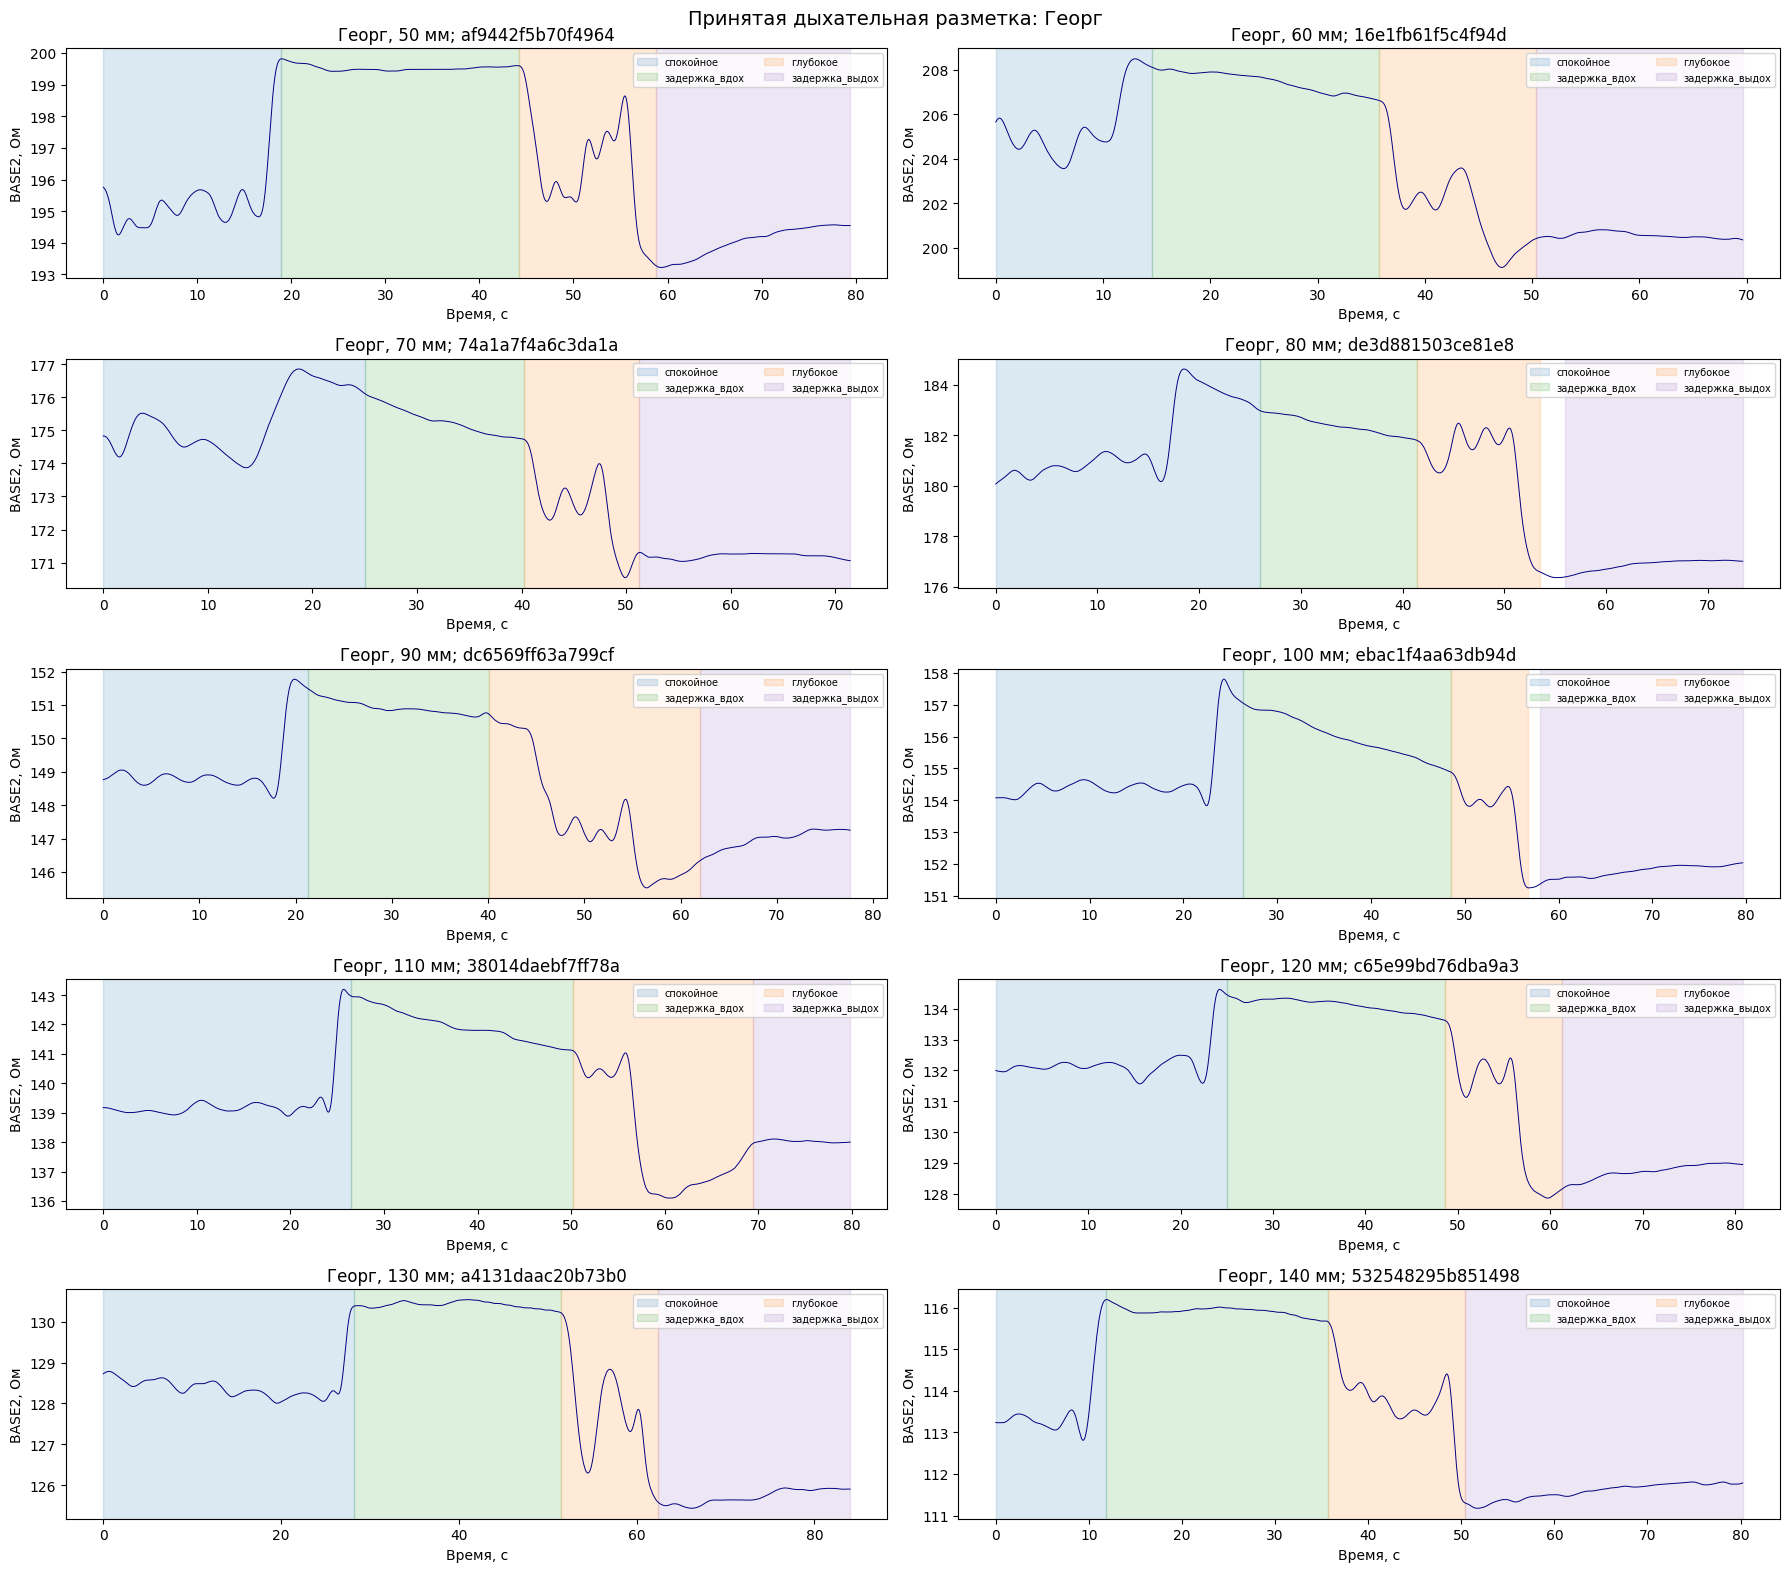

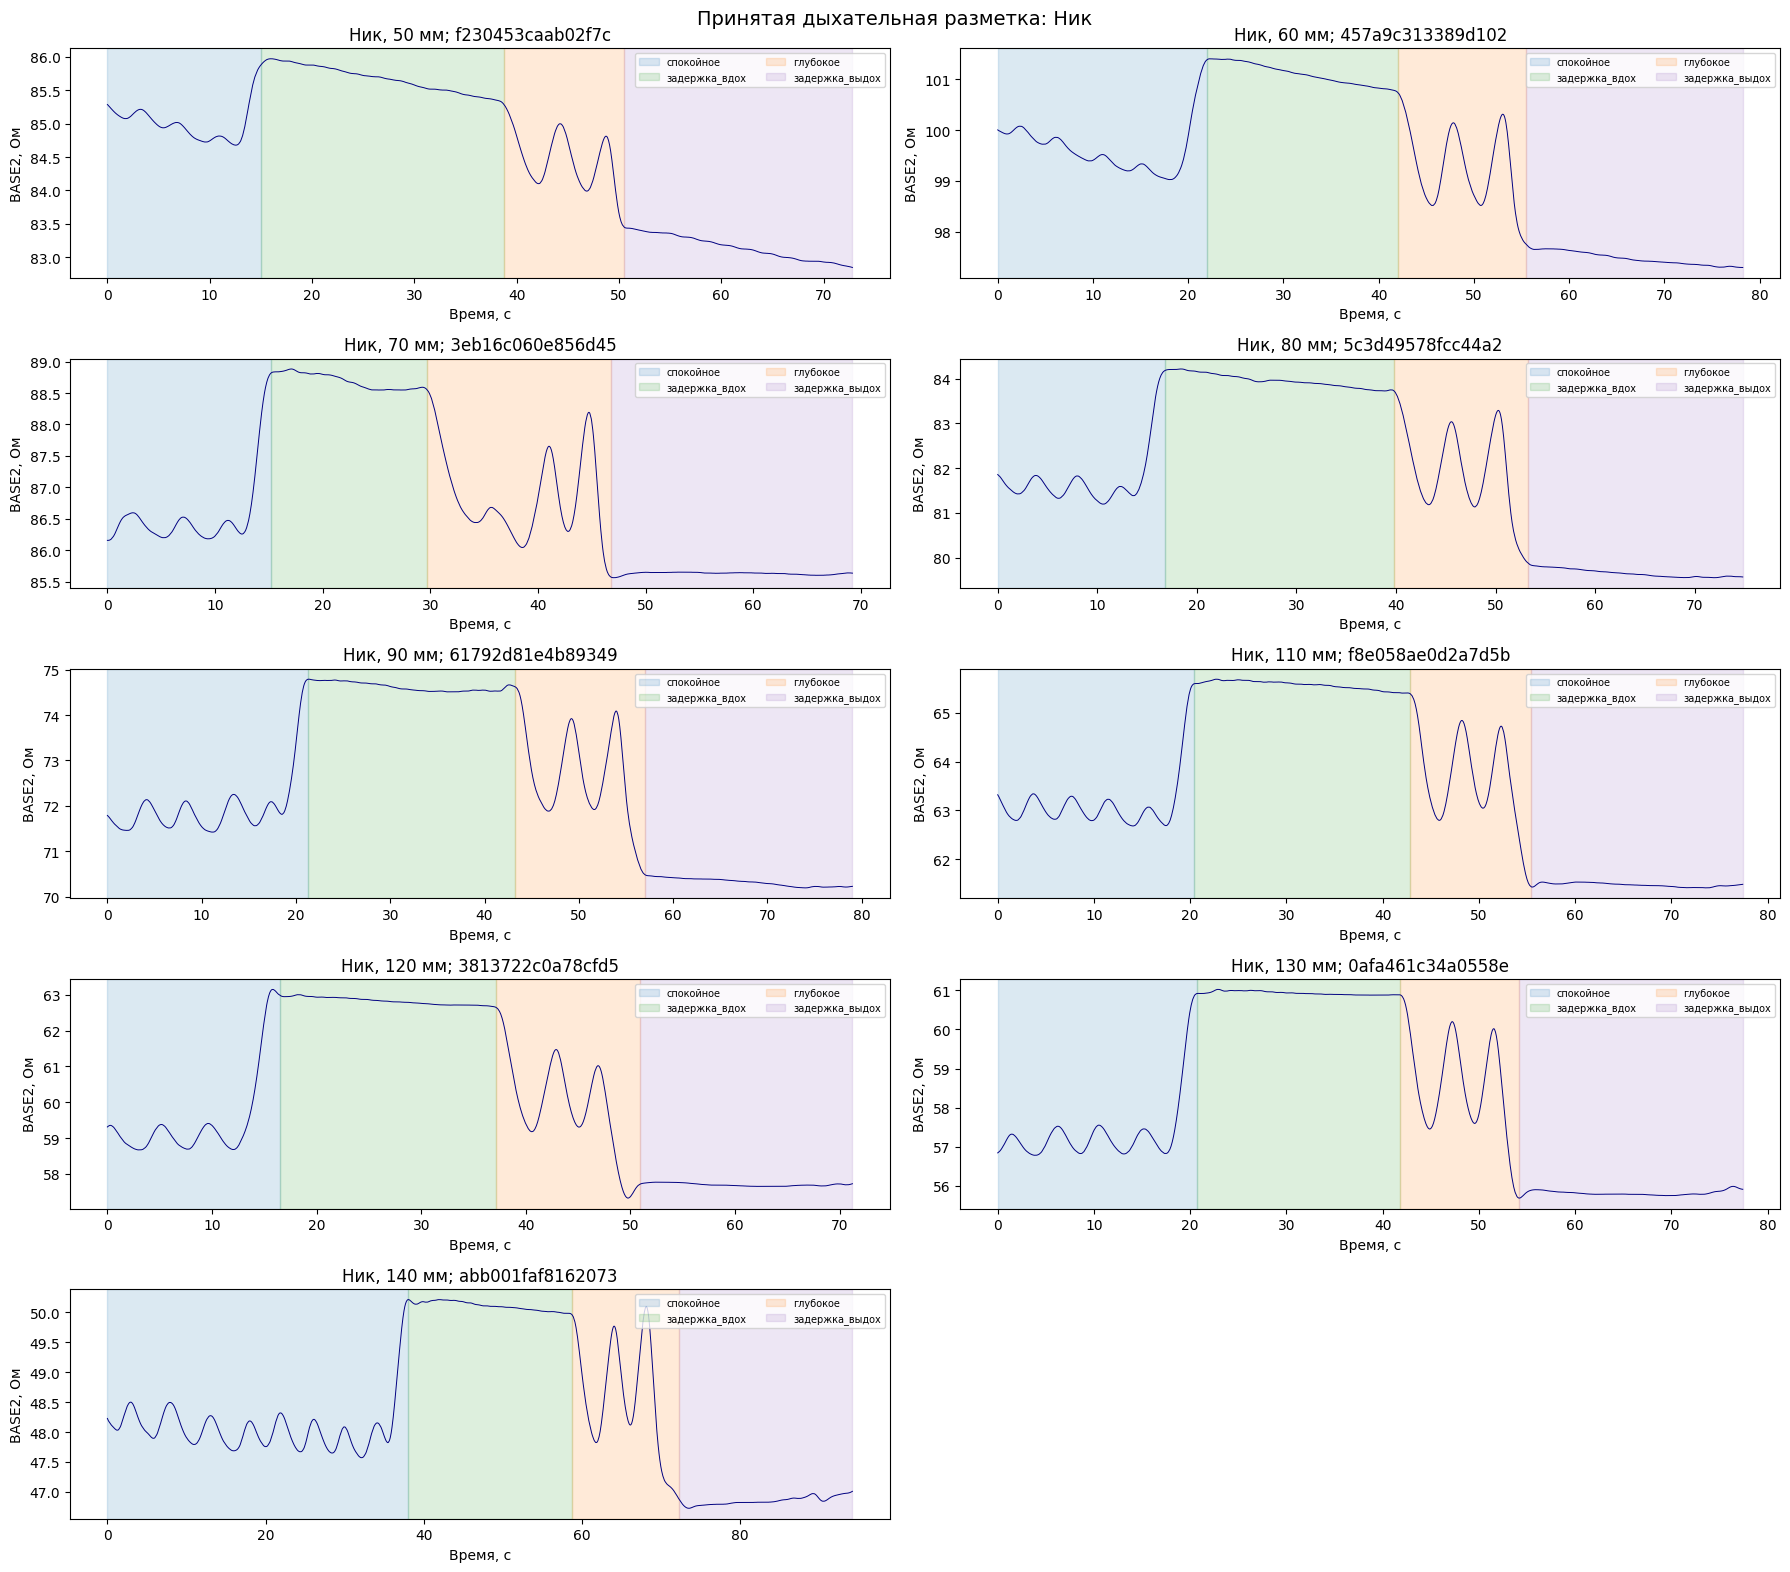

,доброволец,"размер, мм",record_id,текущий статус,решение,уверенность в окнах,"задержка вдох, с","BASE2 вдох, Ом","задержка выдох, с","BASE2 выдох, Ом","разность, Ом"
0,Георг,50,af9442f5b70f4964,принята,утверждена автором,умеренная,18.950–44.235,199.482,58.775–79.420,194.170,5.312
1,Георг,60,16e1fb61f5c4f94d,принята,утверждена автором,умеренная,14.595–35.715,207.626,50.335–69.620,200.511,7.115
2,Георг,70,74a1a7f4a6c3da1a,принята,утверждена автором,умеренная,25.075–40.205,175.277,51.240–71.420,171.211,4.066
3,Георг,80,de3d881503ce81e8,принята,утверждена автором,умеренная,25.950–41.415,182.337,56.000–73.420,176.966,5.371
4,Георг,90,dc6569ff63a799cf,принята,утверждена автором,умеренная,21.325–40.095,150.875,62.015–77.620,147.042,3.833
5,Георг,100,ebac1f4aa63db94d,принята,утверждена автором,умеренная,26.305–48.520,155.902,58.000–79.620,151.820,4.082
6,Георг,110,38014daebf7ff78a,принята,утверждена автором,умеренная,26.435–50.195,141.818,69.475–79.820,138.024,3.794
7,Георг,120,c65e99bd76dba9a3,принята,утверждена автором,умеренная,25.025–48.615,134.209,61.290–80.820,128.727,5.482
8,Георг,130,a4131daac20b73b0,принята,утверждена автором,умеренная,28.215–51.505,130.419,62.460–84.020,125.641,4.778
9,Георг,140,532548295b851498,принята,утверждена автором,умеренная,11.815–35.640,115.915,50.405–80.220,111.636,4.279


In [4]:
# Утверждённые решения по независимым записям
CHECK_RECORD_ID = None
CHECK_SUBJECT_IDS = ["exp02_georg", "exp02_nik"]
CHECK_SIZES_MM = list(range(50, 141, 10))

# Решения привязаны к record_id; sidecar-файлы уже утверждены автором.
ACCEPTED_REVIEW_DECISIONS = [{'record_id': 'af9442f5b70f4964',
  'proposed_status': 'accepted',
  'reviewer': 'Codex: визуальный контроль BASE2; порядок режимов подтверждён автором проекта',
  'proposed_modes': {'спокойное': [0.0, 18.95],
                     'задержка_вдох': [18.95, 44.235],
                     'глубокое': [44.24, 58.775],
                     'задержка_выдох': [58.775, 79.42]},
  'confidence': {'protocol_order': 'high',
                 'stable_hold_windows': 'moderate',
                 'exact_command_boundaries': 'low'},
  'boundary_basis': {'protocol_order': 'author_confirmed_reconstruction',
                     'signal': 'BASE_2_Ω',
                     'visual_features': ['abrupt_baseline_transitions',
                                         'subsequent_stable_segments'],
                     'recorded_command_markers': False},
  'notes': 'Экспертная ретроспективная разметка по форме BASE2. Приборные метки команд '
           'отсутствуют; порядок режимов подтверждён автором проекта. Для количественного '
           'сравнения BASE2 предназначены устойчивые окна задержек, а не моменты начала команд. '
           'Кандидатные границы сохранены без изменения.'},
 {'record_id': '16e1fb61f5c4f94d',
  'proposed_status': 'accepted',
  'reviewer': 'Codex: визуальный контроль BASE2; порядок режимов подтверждён автором проекта',
  'proposed_modes': {'спокойное': [0.0, 14.595],
                     'задержка_вдох': [14.595, 35.715],
                     'глубокое': [35.72, 50.335],
                     'задержка_выдох': [50.335, 69.62]},
  'confidence': {'protocol_order': 'high',
                 'stable_hold_windows': 'moderate',
                 'exact_command_boundaries': 'low'},
  'boundary_basis': {'protocol_order': 'author_confirmed_reconstruction',
                     'signal': 'BASE_2_Ω',
                     'visual_features': ['abrupt_baseline_transitions',
                                         'subsequent_stable_segments'],
                     'recorded_command_markers': False},
  'notes': 'Экспертная ретроспективная разметка по форме BASE2. Приборные метки команд '
           'отсутствуют; порядок режимов подтверждён автором проекта. Для количественного '
           'сравнения BASE2 предназначены устойчивые окна задержек, а не моменты начала команд. '
           'Кандидатные границы сохранены без изменения.'},
 {'record_id': '74a1a7f4a6c3da1a',
  'proposed_status': 'accepted',
  'reviewer': 'Codex: визуальный контроль BASE2; порядок режимов подтверждён автором проекта',
  'proposed_modes': {'спокойное': [0.0, 25.075],
                     'задержка_вдох': [25.075, 40.205],
                     'глубокое': [40.21, 51.24],
                     'задержка_выдох': [51.24, 71.42]},
  'confidence': {'protocol_order': 'high',
                 'stable_hold_windows': 'moderate',
                 'exact_command_boundaries': 'low'},
  'boundary_basis': {'protocol_order': 'author_confirmed_reconstruction',
                     'signal': 'BASE_2_Ω',
                     'visual_features': ['abrupt_baseline_transitions',
                                         'subsequent_stable_segments'],
                     'recorded_command_markers': False},
  'notes': 'Экспертная ретроспективная разметка по форме BASE2. Приборные метки команд '
           'отсутствуют; порядок режимов подтверждён автором проекта. Для количественного '
           'сравнения BASE2 предназначены устойчивые окна задержек, а не моменты начала команд. '
           'Кандидатные границы сохранены без изменения.'},
 {'record_id': 'de3d881503ce81e8',
  'proposed_status': 'accepted',
  'reviewer': 'Codex: визуальный контроль BASE2; порядок режимов подтверждён автором проекта',
  'proposed_modes': {'спокойное': [0.0, 25.95],
                     'задержка_вдох': [25.95, 41.415],
                     'глубокое': [41.42, 53.48],
                     'задержка_выдох': [56.0, 73.42]},
  'confidence': {'protocol_order': 'high',
                 'stable_hold_windows': 'moderate',
                 'exact_command_boundaries': 'low'},
  'boundary_basis': {'protocol_order': 'author_confirmed_reconstruction',
                     'signal': 'BASE_2_Ω',
                     'visual_features': ['abrupt_baseline_transitions',
                                         'subsequent_stable_segments'],
                     'recorded_command_markers': False},
  'notes': 'Экспертная ретроспективная разметка по форме BASE2. Приборные метки команд '
           'отсутствуют; порядок режимов подтверждён автором проекта. Для количественного '
           'сравнения BASE2 предназначены устойчивые окна задержек, а не моменты начала команд. '
           'Начало окна задержки после выдоха перенесено на 56,0 с, чтобы исключить переход к '
           'установившемуся уровню.'},
 {'record_id': 'dc6569ff63a799cf',
  'proposed_status': 'accepted',
  'reviewer': 'Codex: визуальный контроль BASE2; порядок режимов подтверждён автором проекта',
  'proposed_modes': {'спокойное': [0.0, 21.325],
                     'задержка_вдох': [21.325, 40.095],
                     'глубокое': [40.1, 62.015],
                     'задержка_выдох': [62.015, 77.62]},
  'confidence': {'protocol_order': 'high',
                 'stable_hold_windows': 'moderate',
                 'exact_command_boundaries': 'low'},
  'boundary_basis': {'protocol_order': 'author_confirmed_reconstruction',
                     'signal': 'BASE_2_Ω',
                     'visual_features': ['abrupt_baseline_transitions',
                                         'subsequent_stable_segments'],
                     'recorded_command_markers': False},
  'notes': 'Экспертная ретроспективная разметка по форме BASE2. Приборные метки команд '
           'отсутствуют; порядок режимов подтверждён автором проекта. Для количественного '
           'сравнения BASE2 предназначены устойчивые окна задержек, а не моменты начала команд. '
           'Кандидатные границы сохранены без изменения.'},
 {'record_id': 'ebac1f4aa63db94d',
  'proposed_status': 'accepted',
  'reviewer': 'Codex: визуальный контроль BASE2; порядок режимов подтверждён автором проекта',
  'proposed_modes': {'спокойное': [0.0, 26.305],
                     'задержка_вдох': [26.305, 48.52],
                     'глубокое': [48.525, 56.755],
                     'задержка_выдох': [58.0, 79.62]},
  'confidence': {'protocol_order': 'high',
                 'stable_hold_windows': 'moderate',
                 'exact_command_boundaries': 'low'},
  'boundary_basis': {'protocol_order': 'author_confirmed_reconstruction',
                     'signal': 'BASE_2_Ω',
                     'visual_features': ['abrupt_baseline_transitions',
                                         'subsequent_stable_segments'],
                     'recorded_command_markers': False},
  'notes': 'Экспертная ретроспективная разметка по форме BASE2. Приборные метки команд '
           'отсутствуют; порядок режимов подтверждён автором проекта. Для количественного '
           'сравнения BASE2 предназначены устойчивые окна задержек, а не моменты начала команд. '
           'Начало окна задержки после выдоха перенесено на 58,0 с, чтобы исключить переход к '
           'установившемуся уровню.'},
 {'record_id': '38014daebf7ff78a',
  'proposed_status': 'accepted',
  'reviewer': 'Codex: визуальный контроль BASE2; порядок режимов подтверждён автором проекта',
  'proposed_modes': {'спокойное': [0.0, 26.435],
                     'задержка_вдох': [26.435, 50.195],
                     'глубокое': [50.2, 69.475],
                     'задержка_выдох': [69.475, 79.82]},
  'confidence': {'protocol_order': 'high',
                 'stable_hold_windows': 'moderate',
                 'exact_command_boundaries': 'low'},
  'boundary_basis': {'protocol_order': 'author_confirmed_reconstruction',
                     'signal': 'BASE_2_Ω',
                     'visual_features': ['abrupt_baseline_transitions',
                                         'subsequent_stable_segments'],
                     'recorded_command_markers': False},
  'notes': 'Экспертная ретроспективная разметка по форме BASE2. Приборные метки команд '
           'отсутствуют; порядок режимов подтверждён автором проекта. Для количественного '
           'сравнения BASE2 предназначены устойчивые окна задержек, а не моменты начала команд. '
           'Кандидатные границы сохранены без изменения.'},
 {'record_id': 'c65e99bd76dba9a3',
  'proposed_status': 'accepted',
  'reviewer': 'Codex: визуальный контроль BASE2; порядок режимов подтверждён автором проекта',
  'proposed_modes': {'спокойное': [0.0, 25.025],
                     'задержка_вдох': [25.025, 48.615],
                     'глубокое': [48.62, 61.29],
                     'задержка_выдох': [61.29, 80.82]},
  'confidence': {'protocol_order': 'high',
                 'stable_hold_windows': 'moderate',
                 'exact_command_boundaries': 'low'},
  'boundary_basis': {'protocol_order': 'author_confirmed_reconstruction',
                     'signal': 'BASE_2_Ω',
                     'visual_features': ['abrupt_baseline_transitions',
                                         'subsequent_stable_segments'],
                     'recorded_command_markers': False},
  'notes': 'Экспертная ретроспективная разметка по форме BASE2. Приборные метки команд '
           'отсутствуют; порядок режимов подтверждён автором проекта. Для количественного '
           'сравнения BASE2 предназначены устойчивые окна задержек, а не моменты начала команд. '
           'Кандидатные границы сохранены без изменения.'},
 {'record_id': 'a4131daac20b73b0',
  'proposed_status': 'accepted',
  'reviewer': 'Codex: визуальный контроль BASE2; порядок режимов подтверждён автором проекта',
  'proposed_modes': {'спокойное': [0.0, 28.215],
                     'задержка_вдох': [28.215, 51.505],
                     'глубокое': [51.51, 62.46],
                     'задержка_выдох': [62.46, 84.02]},
  'confidence': {'protocol_order': 'high',
                 'stable_hold_windows': 'moderate',
                 'exact_command_boundaries': 'low'},
  'boundary_basis': {'protocol_order': 'author_confirmed_reconstruction',
                     'signal': 'BASE_2_Ω',
                     'visual_features': ['abrupt_baseline_transitions',
                                         'subsequent_stable_segments'],
                     'recorded_command_markers': False},
  'notes': 'Экспертная ретроспективная разметка по форме BASE2. Приборные метки команд '
           'отсутствуют; порядок режимов подтверждён автором проекта. Для количественного '
           'сравнения BASE2 предназначены устойчивые окна задержек, а не моменты начала команд. '
           'Кандидатные границы сохранены без изменения.'},
 {'record_id': '532548295b851498',
  'proposed_status': 'accepted',
  'reviewer': 'Codex: визуальный контроль BASE2; порядок режимов подтверждён автором проекта',
  'proposed_modes': {'спокойное': [0.0, 11.815],
                     'задержка_вдох': [11.815, 35.64],
                     'глубокое': [35.645, 50.405],
                     'задержка_выдох': [50.405, 80.22]},
  'confidence': {'protocol_order': 'high',
                 'stable_hold_windows': 'moderate',
                 'exact_command_boundaries': 'low'},
  'boundary_basis': {'protocol_order': 'author_confirmed_reconstruction',
                     'signal': 'BASE_2_Ω',
                     'visual_features': ['abrupt_baseline_transitions',
                                         'subsequent_stable_segments'],
                     'recorded_command_markers': False},
  'notes': 'Экспертная ретроспективная разметка по форме BASE2. Приборные метки команд '
           'отсутствуют; порядок режимов подтверждён автором проекта. Для количественного '
           'сравнения BASE2 предназначены устойчивые окна задержек, а не моменты начала команд. '
           'Кандидатные границы сохранены без изменения.'},
 {'record_id': 'f230453caab02f7c',
  'proposed_status': 'accepted',
  'reviewer': 'Codex: визуальный контроль BASE2; порядок режимов подтверждён автором проекта',
  'proposed_modes': {'спокойное': [0.0, 15.005],
                     'задержка_вдох': [15.005, 38.77],
                     'глубокое': [38.775, 50.51],
                     'задержка_выдох': [50.51, 72.82]},
  'confidence': {'protocol_order': 'high',
                 'stable_hold_windows': 'moderate',
                 'exact_command_boundaries': 'low'},
  'boundary_basis': {'protocol_order': 'author_confirmed_reconstruction',
                     'signal': 'BASE_2_Ω',
                     'visual_features': ['abrupt_baseline_transitions',
                                         'subsequent_stable_segments'],
                     'recorded_command_markers': False},
  'notes': 'Экспертная ретроспективная разметка по форме BASE2. Приборные метки команд '
           'отсутствуют; порядок режимов подтверждён автором проекта. Для количественного '
           'сравнения BASE2 предназначены устойчивые окна задержек, а не моменты начала команд. '
           'Кандидатные границы сохранены без изменения.'},
 {'record_id': '457a9c313389d102',
  'proposed_status': 'accepted',
  'reviewer': 'Codex: визуальный контроль BASE2; порядок режимов подтверждён автором проекта',
  'proposed_modes': {'спокойное': [0.0, 21.945],
                     'задержка_вдох': [21.945, 41.975],
                     'глубокое': [41.98, 55.505],
                     'задержка_выдох': [55.505, 78.22]},
  'confidence': {'protocol_order': 'high',
                 'stable_hold_windows': 'moderate',
                 'exact_command_boundaries': 'low'},
  'boundary_basis': {'protocol_order': 'author_confirmed_reconstruction',
                     'signal': 'BASE_2_Ω',
                     'visual_features': ['abrupt_baseline_transitions',
                                         'subsequent_stable_segments'],
                     'recorded_command_markers': False},
  'notes': 'Экспертная ретроспективная разметка по форме BASE2. Приборные метки команд '
           'отсутствуют; порядок режимов подтверждён автором проекта. Для количественного '
           'сравнения BASE2 предназначены устойчивые окна задержек, а не моменты начала команд. '
           'Кандидатные границы сохранены без изменения.'},
 {'record_id': '3eb16c060e856d45',
  'proposed_status': 'accepted',
  'reviewer': 'Codex: визуальный контроль BASE2; порядок режимов подтверждён автором проекта',
  'proposed_modes': {'спокойное': [0.0, 15.235],
                     'задержка_вдох': [15.235, 29.66],
                     'глубокое': [29.665, 46.745],
                     'задержка_выдох': [46.745, 69.22]},
  'confidence': {'protocol_order': 'high',
                 'stable_hold_windows': 'moderate',
                 'exact_command_boundaries': 'low'},
  'boundary_basis': {'protocol_order': 'author_confirmed_reconstruction',
                     'signal': 'BASE_2_Ω',
                     'visual_features': ['abrupt_baseline_transitions',
                                         'subsequent_stable_segments'],
                     'recorded_command_markers': False},
  'notes': 'Экспертная ретроспективная разметка по форме BASE2. Приборные метки команд '
           'отсутствуют; порядок режимов подтверждён автором проекта. Для количественного '
           'сравнения BASE2 предназначены устойчивые окна задержек, а не моменты начала команд. '
           'Кандидатные границы сохранены без изменения.'},
 {'record_id': '5c3d49578fcc44a2',
  'proposed_status': 'accepted',
  'reviewer': 'Codex: визуальный контроль BASE2; порядок режимов подтверждён автором проекта',
  'proposed_modes': {'спокойное': [0.0, 16.75],
                     'задержка_вдох': [16.75, 39.75],
                     'глубокое': [39.755, 53.24],
                     'задержка_выдох': [53.24, 74.82]},
  'confidence': {'protocol_order': 'high',
                 'stable_hold_windows': 'moderate',
                 'exact_command_boundaries': 'low'},
  'boundary_basis': {'protocol_order': 'author_confirmed_reconstruction',
                     'signal': 'BASE_2_Ω',
                     'visual_features': ['abrupt_baseline_transitions',
                                         'subsequent_stable_segments'],
                     'recorded_command_markers': False},
  'notes': 'Экспертная ретроспективная разметка по форме BASE2. Приборные метки команд '
           'отсутствуют; порядок режимов подтверждён автором проекта. Для количественного '
           'сравнения BASE2 предназначены устойчивые окна задержек, а не моменты начала команд. '
           'Кандидатные границы сохранены без изменения.'},
 {'record_id': '61792d81e4b89349',
  'proposed_status': 'accepted',
  'reviewer': 'Codex: визуальный контроль BASE2; порядок режимов подтверждён автором проекта',
  'proposed_modes': {'спокойное': [0.0, 21.23],
                     'задержка_вдох': [21.23, 43.26],
                     'глубокое': [43.265, 56.97],
                     'задержка_выдох': [56.97, 79.02]},
  'confidence': {'protocol_order': 'high',
                 'stable_hold_windows': 'moderate',
                 'exact_command_boundaries': 'low'},
  'boundary_basis': {'protocol_order': 'author_confirmed_reconstruction',
                     'signal': 'BASE_2_Ω',
                     'visual_features': ['abrupt_baseline_transitions',
                                         'subsequent_stable_segments'],
                     'recorded_command_markers': False},
  'notes': 'Экспертная ретроспективная разметка по форме BASE2. Приборные метки команд '
           'отсутствуют; порядок режимов подтверждён автором проекта. Для количественного '
           'сравнения BASE2 предназначены устойчивые окна задержек, а не моменты начала команд. '
           'Кандидатные границы сохранены без изменения.'},
 {'record_id': 'f8e058ae0d2a7d5b',
  'proposed_status': 'accepted',
  'reviewer': 'Codex: визуальный контроль BASE2; порядок режимов подтверждён автором проекта',
  'proposed_modes': {'спокойное': [0.0, 20.39],
                     'задержка_вдох': [20.39, 42.865],
                     'глубокое': [42.87, 55.415],
                     'задержка_выдох': [55.415, 77.42]},
  'confidence': {'protocol_order': 'high',
                 'stable_hold_windows': 'moderate',
                 'exact_command_boundaries': 'low'},
  'boundary_basis': {'protocol_order': 'author_confirmed_reconstruction',
                     'signal': 'BASE_2_Ω',
                     'visual_features': ['abrupt_baseline_transitions',
                                         'subsequent_stable_segments'],
                     'recorded_command_markers': False},
  'notes': 'Экспертная ретроспективная разметка по форме BASE2. Приборные метки команд '
           'отсутствуют; порядок режимов подтверждён автором проекта. Для количественного '
           'сравнения BASE2 предназначены устойчивые окна задержек, а не моменты начала команд. '
           'Кандидатные границы сохранены без изменения.'},
 {'record_id': '3813722c0a78cfd5',
  'proposed_status': 'accepted',
  'reviewer': 'Codex: визуальный контроль BASE2; порядок режимов подтверждён автором проекта',
  'proposed_modes': {'спокойное': [0.0, 16.455],
                     'задержка_вдох': [16.455, 37.105],
                     'глубокое': [37.11, 50.88],
                     'задержка_выдох': [50.88, 71.22]},
  'confidence': {'protocol_order': 'high',
                 'stable_hold_windows': 'moderate',
                 'exact_command_boundaries': 'low'},
  'boundary_basis': {'protocol_order': 'author_confirmed_reconstruction',
                     'signal': 'BASE_2_Ω',
                     'visual_features': ['abrupt_baseline_transitions',
                                         'subsequent_stable_segments'],
                     'recorded_command_markers': False},
  'notes': 'Экспертная ретроспективная разметка по форме BASE2. Приборные метки команд '
           'отсутствуют; порядок режимов подтверждён автором проекта. Для количественного '
           'сравнения BASE2 предназначены устойчивые окна задержек, а не моменты начала команд. '
           'Кандидатные границы сохранены без изменения.'},
 {'record_id': '0afa461c34a0558e',
  'proposed_status': 'accepted',
  'reviewer': 'Codex: визуальный контроль BASE2; порядок режимов подтверждён автором проекта',
  'proposed_modes': {'спокойное': [0.0, 20.68],
                     'задержка_вдох': [20.68, 41.84],
                     'глубокое': [41.845, 54.165],
                     'задержка_выдох': [54.165, 77.42]},
  'confidence': {'protocol_order': 'high',
                 'stable_hold_windows': 'moderate',
                 'exact_command_boundaries': 'low'},
  'boundary_basis': {'protocol_order': 'author_confirmed_reconstruction',
                     'signal': 'BASE_2_Ω',
                     'visual_features': ['abrupt_baseline_transitions',
                                         'subsequent_stable_segments'],
                     'recorded_command_markers': False},
  'notes': 'Экспертная ретроспективная разметка по форме BASE2. Приборные метки команд '
           'отсутствуют; порядок режимов подтверждён автором проекта. Для количественного '
           'сравнения BASE2 предназначены устойчивые окна задержек, а не моменты начала команд. '
           'Кандидатные границы сохранены без изменения.'},
 {'record_id': 'abb001faf8162073',
  'proposed_status': 'accepted',
  'reviewer': 'Codex: визуальный контроль BASE2; порядок режимов подтверждён автором проекта',
  'proposed_modes': {'спокойное': [0.0, 37.96],
                     'задержка_вдох': [37.96, 58.735],
                     'глубокое': [58.74, 72.295],
                     'задержка_выдох': [72.295, 94.22]},
  'confidence': {'protocol_order': 'high',
                 'stable_hold_windows': 'moderate',
                 'exact_command_boundaries': 'low'},
  'boundary_basis': {'protocol_order': 'author_confirmed_reconstruction',
                     'signal': 'BASE_2_Ω',
                     'visual_features': ['abrupt_baseline_transitions',
                                         'subsequent_stable_segments'],
                     'recorded_command_markers': False},
  'notes': 'Экспертная ретроспективная разметка по форме BASE2. Приборные метки команд '
           'отсутствуют; порядок режимов подтверждён автором проекта. Для количественного '
           'сравнения BASE2 предназначены устойчивые окна задержек, а не моменты начала команд. '
           'Кандидатные границы сохранены без изменения.'}]

MODE_ORDER = [
    "спокойное",
    "задержка_вдох",
    "глубокое",
    "задержка_выдох",
]


def validate_modes(modes, start_s, stop_s):
    if not isinstance(modes, dict) or list(modes) != MODE_ORDER:
        raise ValueError(f"Режимы должны идти в порядке {MODE_ORDER}")
    previous_stop = start_s
    normalized = {}
    for name in MODE_ORDER:
        interval = modes[name]
        if not isinstance(interval, list) or len(interval) != 2:
            raise ValueError(f"Интервал {name} должен содержать начало и конец")
        left, right = map(float, interval)
        if not np.isfinite([left, right]).all() or not start_s <= left < right <= stop_s:
            raise ValueError(f"Недопустимые границы интервала {name}")
        if left < previous_stop:
            raise ValueError(f"Интервалы перекрываются перед {name}")
        normalized[name] = [left, right]
        previous_stop = right
    return normalized


def load_annotation(record_id):
    sidecar_path = OUT_DIR / f"{record_id}.json"
    annotation = json.loads(sidecar_path.read_text(encoding="utf-8"))
    source_path = resolve_under_data_root(
        DATA_ROOT / annotation["input"]["relative_path"]
    )
    if sha256_file(source_path) != annotation["input"]["sha256"]:
        raise RuntimeError("SHA-256 исходного CSV изменился после разметки")
    return annotation, read_record(source_path)


proposal_by_id = {item["record_id"]: item for item in ACCEPTED_REVIEW_DECISIONS}
record_ids_in_run = {annotation["record_id"] for annotation in records}
if len(proposal_by_id) != len(ACCEPTED_REVIEW_DECISIONS):
    raise ValueError("В ACCEPTED_REVIEW_DECISIONS повторяется record_id")
if set(proposal_by_id) != record_ids_in_run:
    missing = sorted(record_ids_in_run - set(proposal_by_id))
    stale = sorted(set(proposal_by_id) - record_ids_in_run)
    raise RuntimeError(
        "Проверенные предложения не совпали с текущими данными: "
        f"нет предложений={missing}, устарели={stale}"
    )

if CHECK_RECORD_ID is not None:
    selected_record_ids = [CHECK_RECORD_ID]
else:
    selected_record_ids = [
        annotation["record_id"]
        for annotation in records
        if annotation["subject_id"] in CHECK_SUBJECT_IDS
        and annotation["size_mm"] in CHECK_SIZES_MM
    ]
    subject_order = {subject_id: index for index, subject_id in enumerate(CHECK_SUBJECT_IDS)}
    annotation_by_id = {annotation["record_id"]: annotation for annotation in records}
    selected_record_ids.sort(
        key=lambda record_id: (
            subject_order[annotation_by_id[record_id]["subject_id"]],
            annotation_by_id[record_id]["size_mm"],
        )
    )

selected_records = [(*load_annotation(record_id),) for record_id in selected_record_ids]
summary_rows = []
mode_colors = {
    "спокойное": "tab:blue",
    "задержка_вдох": "tab:green",
    "глубокое": "tab:orange",
    "задержка_выдох": "tab:purple",
}
subject_labels = {"exp02_georg": "Георг", "exp02_nik": "Ник"}

for subject_id in CHECK_SUBJECT_IDS:
    subject_records = [
        (annotation, frame)
        for annotation, frame in selected_records
        if annotation["subject_id"] == subject_id
    ]
    if not subject_records:
        continue
    ncols = 2
    nrows = (len(subject_records) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3.2 * nrows), squeeze=False)
    flat_axes = axes.ravel()

    for axis, (annotation, frame) in zip(flat_axes, subject_records):
        record_id = annotation["record_id"]
        proposal = proposal_by_id[record_id]
        time = frame[TIME_COL].to_numpy(dtype=float)
        signal = frame[SEG_COL].to_numpy(dtype=float)
        modes = validate_modes(
            proposal["proposed_modes"],
            float(time[0]),
            float(time[-1]),
        )
        sidecar_status = annotation.get("qc", {}).get("status")
        if sidecar_status != "accepted":
            raise RuntimeError(f"Разметка {record_id} не утверждена")
        if annotation.get("accepted_modes") != modes:
            raise RuntimeError(f"Принятые интервалы {record_id} не совпали с решением")

        levels = {}
        for mode_name in ("задержка_вдох", "задержка_выдох"):
            start, stop = modes[mode_name]
            mask = (time >= start) & (time <= stop)
            levels[mode_name] = float(np.median(signal[mask]))

        summary_rows.append({
            "доброволец": subject_labels.get(subject_id, subject_id),
            "размер, мм": annotation["size_mm"],
            "record_id": record_id,
            "текущий статус": {
                "pending_manual_review": "ожидает ручного подтверждения",
                "accepted": "принята",
                "rejected": "отклонена",
            }.get(sidecar_status, sidecar_status),
            "решение": "утверждена автором",
            "уверенность в окнах": {
                "low": "низкая",
                "moderate": "умеренная",
                "high": "высокая",
            }[proposal["confidence"]["stable_hold_windows"]],
            "задержка вдох, с": "{:.3f}–{:.3f}".format(*modes["задержка_вдох"]),
            "BASE2 вдох, Ом": levels["задержка_вдох"],
            "задержка выдох, с": "{:.3f}–{:.3f}".format(*modes["задержка_выдох"]),
            "BASE2 выдох, Ом": levels["задержка_выдох"],
            "разность, Ом": levels["задержка_вдох"] - levels["задержка_выдох"],
        })

        axis.plot(time, signal, color="navy", linewidth=0.7)
        for name, (start, stop) in modes.items():
            axis.axvspan(start, stop, color=mode_colors[name], alpha=0.16, label=name)
        axis.set_ylabel("BASE2, Ом")
        axis.set_title(
            f"{subject_labels.get(subject_id, subject_id)}, "
            f"{annotation['size_mm']} мм; {record_id}"
        )
        axis.legend(loc="upper right", ncol=2, fontsize=7)
        axis.set_xlabel("Время, с")

    for axis in flat_axes[len(subject_records):]:
        axis.set_visible(False)
    fig.suptitle(
        f"Принятая дыхательная разметка: {subject_labels.get(subject_id, subject_id)}",
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()

review_summary = pd.DataFrame(summary_rows)
numeric_columns = ["BASE2 вдох, Ом", "BASE2 выдох, Ом", "разность, Ом"]
review_summary[numeric_columns] = review_summary[numeric_columns].round(3)
review_summary["порядок добровольца"] = review_summary["доброволец"].map({"Георг": 0, "Ник": 1})
review_summary = review_summary.sort_values(
    ["порядок добровольца", "размер, мм"]
).drop(columns="порядок добровольца")
display(review_summary.reset_index(drop=True))


## Результат и зависимые этапы

Для 19 независимых записей эксперимента 2 приняты рабочие границы четырёх
дыхательных режимов. Запись Ника 100 мм не входит в этот набор, поскольку в
`10.01` она подтверждена как побайтовая копия записи 90 мм.

Принятые окна задержек можно использовать для вычисления устойчивых уровней
`BASE2` на вдохе и выдохе. Они не являются измеренными моментами подачи команд
и не предназначены для оценки времени реакции испытуемого. Границы спокойного
и усиленного дыхания служат рабочим разделением записи и имеют меньшую
временную точность, чем устойчивые окна задержек.

Канонические сопроводительные файлы находятся во внешнем каталоге
`derived/exp02/annotations/breathing/`. В Git допускаются только схема и
обезличенный пример.

[`11.02`](11.02_Разметка_ЭКГ_эксперимента_2.ipynb) связывает ЭКГ-разметку с
той же записью по идентификатору и полной контрольной сумме исходного CSV.
Последующие расчёты должны использовать принятые интервалы и отдельно
учитывать ограничения записей, зафиксированные в
[`10.01`](10.01_QC_эксперимента_2_порядок_и_каналы.ipynb).
